In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
 # Chargement de la base de données IRIS
X = load_iris() .data
y = load_iris() .target
# Spliting de la BD
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2, random_state=42)

In [4]:

#Implémentation de l’algorithme KNN

def KNN_predict_Examples(X_train,y_train, X_test, y_test, k=2):
        predictions = []
        for example in X_test:
            #distances = [np.linalg.norm(example - x) for x in X_train]
            #Ou bien
            distances = [mean_squared_error(example,x) for x in X_train]

            k_indices = np.argsort(distances)[:k]
            k_nearest_labels = [y_train[i] for i in k_indices]
            most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
            predictions.append(most_common)
        return predictions



In [5]:
predictions =KNN_predict_Examples(X_train,y_train, X_test, y_test, k=2)
print("Predictions:", predictions)
print("Réel:", y_test)

Predictions: [1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0]
Réel: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [10]:
def accuracy(y_test, predictions):
    accuracy = np.sum(y_test == predictions) / len(y_test)
    return accuracy

In [11]:
accuracy(y_test, predictions)

1.0

In [21]:
def studyKNN(X_train,y_train, X_test, y_test):
  listErr=[]
  for k in range(1,20):
    predictions =KNN_predict_Examples(X_train,y_train, X_test, y_test, k)

    acc=accuracy(y_test, predictions)
    #ou bien
    #acc=r2_score(y_test, predictions)


    listErr.append(acc)

  x_axes_val=range(1,20)

  plt.scatter(x_axes_val,listErr, c="b")
  plt.plot(x_axes_val,listErr, c="r")

  plt.title("Accuracy en fonction de k")
  plt.xlabel("k")
  plt.ylabel("Accuracy")
  plt.xticks(x_axes_val)
  plt.show()

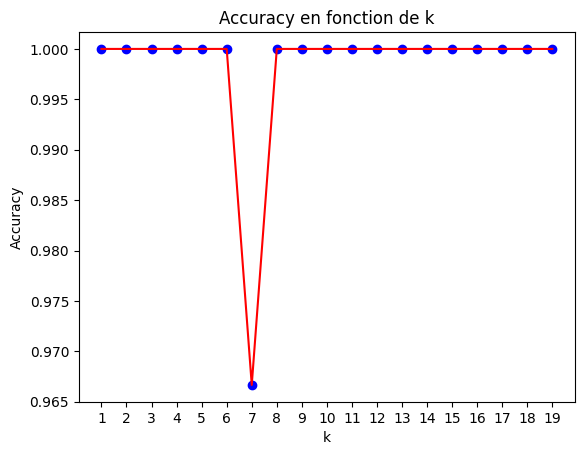

In [22]:
studyKNN(X_train,y_train, X_test, y_test)